# Phase 4: The Spatial-Temporal Grand Merge
**Author:** Oyinlayefa Mezeh  
**Date:** March 2026  

**Objective:** This notebook performs the final integration of the four master datasets (WFP Prices, ACLED Conflict, EM-DAT Drought, and World Bank GDP). It systematically resolves structural discrepancies (spatial naming conventions, temporal granularity, and missing exposure data) via a Left-Join architecture, preserving the WFP price observations as the primary dependent variable.

**Output:** `nigeria_analytical_master.csv` (Dashboard & Regression Ready)

## 1. Load Data & Resolve Spatial Discrepancies
We load the four isolated datasets. To allow the WFP data to merge with ACLED and EM-DAT, we must standardize the regional join key by renaming `admin1` to `adm1_name`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the 4 Master Datasets
# Note: Using the exact filenames from your environment
df_wfp = pd.read_csv('wfp_nigeria_staples_clean.csv')
df_acled = pd.read_csv('02_ACLED_Nigeria_clean.csv')
df_drought = pd.read_csv('nigeria_drought_master_v2.csv')
df_gdp = pd.read_csv('nigeria_gdp_master.csv')

# --- DISCREPANCY 1 FIX: Spatial Naming ---
# Rename WFP state column to match ACLED and EM-DAT
df_wfp = df_wfp.rename(columns={'admin1': 'adm1_name'})

# Standardize text formatting (Title Case) to prevent case-sensitive join failures
df_wfp['adm1_name'] = df_wfp['adm1_name'].str.title()
df_acled['adm1_name'] = df_acled['adm1_name'].str.title()
df_drought['adm1_name'] = df_drought['adm1_name'].str.title()

print("✅ Data loaded and Spatial Keys aligned.")

✅ Data loaded and Spatial Keys aligned.


## 2. Temporal Normalization & Left Joins
Because ACLED and WFP are recorded mid-month and EM-DAT is recorded on the 1st of the month, we convert all temporal keys to a strict `Year-Month` period format. We then perform a series of Left Joins to attach environmental, societal, and macroeconomic shocks to the baseline food prices.

In [ ]:
# --- DISCREPANCY 2 FIX: Temporal Alignment ---
# Convert all date columns to a uniform Year-Month format (e.g., '2015-05')
df_wfp['join_date'] = pd.to_datetime(df_wfp['date']).dt.to_period('M')
df_acled['join_date'] = pd.to_datetime(df_acled['date']).dt.to_period('M')
df_drought['join_date'] = pd.to_datetime(df_drought['date']).dt.to_period('M')

# Calculate 'conflict_frequency' for df_acled as the sum of battle_count and riot_count
df_acled['conflict_frequency'] = df_acled['battle_count'] + df_acled['riot_count']

# Merge 1: WFP (Prices) + ACLED (Conflict)
# We now bring over battle_count and riot_count separately, in addition to conflict_frequency and conflict_intensity
df_master = pd.merge(
    df_wfp,
    df_acled[['join_date', 'adm1_name', 'battle_count', 'riot_count', 'conflict_frequency', 'conflict_intensity']],
    on=['join_date', 'adm1_name'],
    how='left'
)

# Merge 2: Master + EM-DAT (Drought)
df_master = pd.merge(
    df_master,
    df_drought[['join_date', 'adm1_name', 'Drought_Active', 'Affected_Severity']],
    on=['join_date', 'adm1_name'],
    how='left'
)

# --- DISCREPANCY 4 FIX: Macroeconomic Granularity ---
# GDP is annual. We extract the year from our WFP date to broadcast the GDP value across all 12 months.
df_master['join_year'] = df_master['join_date'].dt.year
df_master['iso3'] = 'NGA' # Ensure ISO3 exists for the GDP join

# Merge 3: Master + World Bank (GDP)
df_master = pd.merge(
    df_master,
    df_gdp[['year', 'iso3', 'gdp_per_capita_usd']],
    left_on=['join_year', 'iso3'],
    right_on=['year', 'iso3'],
    how='left'
)

print(f"✅ Grand Merge Complete. Master dataset holds {len(df_master)} observations.")

✅ Grand Merge Complete. Master dataset holds 8269 observations.


## 3. Resolving Null Scopes & Exporting
A Left Join naturally produces `NaN` (Null) values for states/months where no conflict or drought occurred. For quantitative analysis, these must be explicitly converted to `0` (indicating zero events/severity rather than missing data).

In [ ]:
# --- DISCREPANCY 3 FIX: Null Handling ---
# Convert NaN to 0 for specific quantitative indicator columns
# Added 'battle_count' and 'riot_count' to fill with zeros
fill_zero_cols = ['conflict_frequency', 'conflict_intensity', 'battle_count', 'riot_count', 'Drought_Active', 'Affected_Severity']

for col in fill_zero_cols:
    if col in df_master.columns:
        df_master[col] = df_master[col].fillna(0)

# Clean up redundant columns used for joining
drop_cols = ['join_date', 'join_year', 'year_y'] # Drop WBs 'year' column to avoid duplicates
df_master = df_master.drop(columns=[c for c in drop_cols if c in df_master.columns])
df_master = df_master.rename(columns={'year_x': 'year'})

# Final Export
output_file = 'nigeria_analytical_master.csv'
df_master.to_csv(output_file, index=False)

print(f"💾 Analytical Master successfully saved to: {output_file}")

# Display a preview of the final unified dashboard dataset!
display(df_master.head())
display(df_master.info())

💾 Analytical Master successfully saved to: nigeria_analytical_master.csv


,countryiso3,date,adm1_name,admin2,market,market_id,latitude,longitude,category,product,...,Unit_Weight,Price_Norm,battle_count,riot_count,conflict_frequency,conflict_intensity,Drought_Active,Affected_Severity,iso3,gdp_per_capita_usd
0,NGA,2010-01-15,Borno,Mobbar,Damassack (CBM),1040,13.01,12.56,cereals and tubers,Maize,...,1.0,157.57,0.0,0.0,0.0,0.0,0.0,0.0,NGA,6301.183725
1,NGA,2010-01-15,Borno,Mobbar,Damassack (CBM),1040,13.01,12.56,cereals and tubers,Rice (imported),...,1.0,413.33,0.0,0.0,0.0,0.0,0.0,0.0,NGA,6301.183725
2,NGA,2010-01-15,Jigawa,Maigatari,Mai Gatari (CBM),1041,12.78,9.44,cereals and tubers,Maize,...,1.0,180.40,0.0,0.0,0.0,0.0,0.0,0.0,NGA,6301.183725
3,NGA,2010-01-15,Jigawa,Maigatari,Mai Gatari (CBM),1041,12.78,9.44,cereals and tubers,Rice (imported),...,1.0,413.33,0.0,0.0,0.0,0.0,0.0,0.0,NGA,6301.183725
4,NGA,2010-01-15,Kano,Dawakin Tofa,Dawanau,1976,12.09,8.43,cereals and tubers,Maize (white),...,100.0,53.00,0.0,0.0,0.0,0.0,0.0,0.0,NGA,6301.183725


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8269 entries, 0 to 8268
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   countryiso3         8269 non-null   object 
 1   date                8269 non-null   object 
 2   adm1_name           8269 non-null   object 
 3   admin2              8269 non-null   object 
 4   market              8269 non-null   object 
 5   market_id           8269 non-null   int64  
 6   latitude            8269 non-null   float64
 7   longitude           8269 non-null   float64
 8   category            8269 non-null   object 
 9   product             8269 non-null   object 
 10  commodity_id        8269 non-null   int64  
 11  unit                8269 non-null   object 
 12  priceflag           8269 non-null   object 
 13  pricetype           8269 non-null   object 
 14  currency            8269 non-null   object 
 15  mp_price            8269 non-null   float64
 16  usdpri

None

## 3. Correlation Matrix.

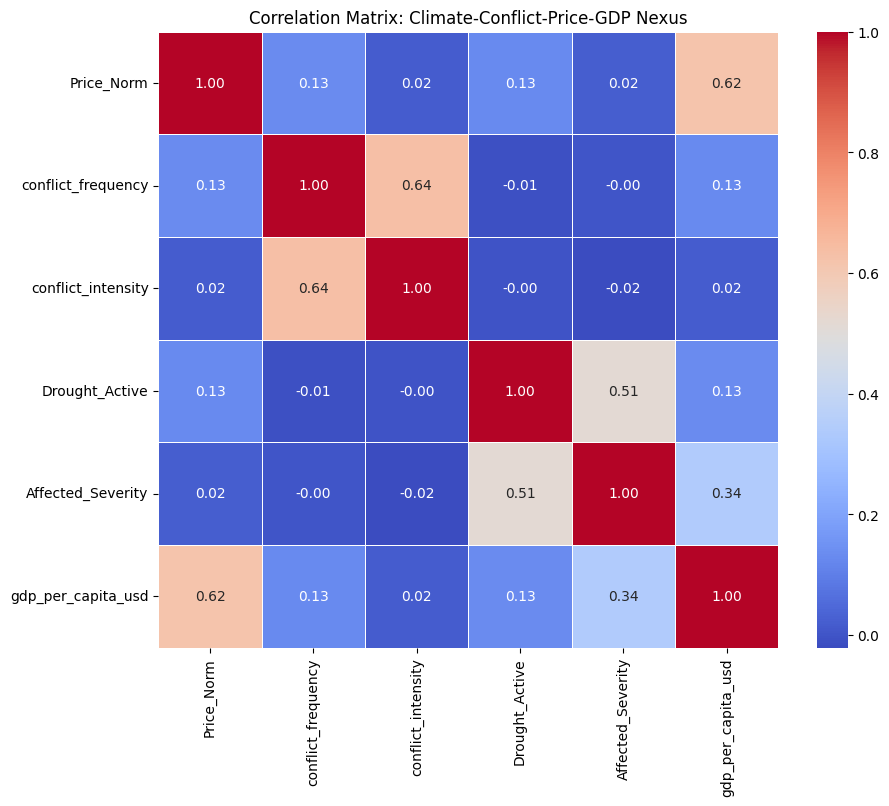

In [ ]:
import seaborn as sns

# Select the core indicators for the causal chain
indicators = [
    'Price_Norm', 'conflict_frequency', 'conflict_intensity',
    'Drought_Active', 'Affected_Severity', 'gdp_per_capita_usd'
]

# Calculate the correlation matrix
corr_matrix = df_master[indicators].corr()

# Visualize the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Climate-Conflict-Price-GDP Nexus")
plt.show()